**Proyecto 1: Análisis y Predicción de Ventas en una Tienda de Retail**

**Objetivo:** Realizar un análisis exploratorio de datos (EDA) completo, preprocesamiento y benchmarking de técnicas de machine learning para predecir ventas en una tienda de retail. Además, generar un análisis de métricas y crear una presentación de una página (one-page) en PPT para explicar los resultados. Todo el trabajo debe ser subido como una versión de liberación (v1.0.0) en GitHub.

# Parte 1
###1.1 Carga y Exploración Inicial de Datos:
* Cargar el dataset y revisar su estructura básica.
* Describir las variables y su distribución.
* Identificar y tratar valores nulos y outliers.

In [58]:
# Cargar el dataset y revisar su estructura básica.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')

In [59]:
# Primeros registros
print("Primeros registros:")
print(df.head())

Primeros registros:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [60]:
# Dimensiones del dataset
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}\nColumnas: {df.shape[1]}")

Dimensiones del dataset:
Filas: 1000
Columnas: 9


In [61]:
# Verificación de datos nulos
print("Verificación de datos nulos:")
print(df.isnull().sum())

Verificación de datos nulos:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [62]:
print("Descripción de las variables:")
print(df.describe())

Descripción de las variables:
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000


In [63]:
# Información general
print("Información general:")
print(df.info())

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None


In [64]:
# Detección de registros duplicados
print("Registros duplicados:")
print(df.duplicated().sum())

Registros duplicados:
0


In [65]:
# Eliminación de la columna Transacción ID
df = df.drop('Transaction ID', axis=1)

# Corrección de datos inconsistentes
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip().lower() if isinstance(x, str) else x)

# Correción de nombres de columnas inconsistentes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)

print(df.head())

         date customer_id  gender  age product_category  quantity  \
0  2023-11-24     cust001    male   34           beauty         3   
1  2023-02-27     cust002  female   26         clothing         2   
2  2023-01-13     cust003    male   50      electronics         1   
3  2023-05-21     cust004    male   37         clothing         1   
4  2023-05-06     cust005    male   30           beauty         2   

   price_per_unit  total_amount  
0              50           150  
1             500          1000  
2              30            30  
3             500           500  
4              50           100  


In [66]:
# Convertir object a category excepto Date
for col in df.columns:
    if df[col].dtype == 'object' and df[col].name != 'date':
        df[col] = df[col].astype('category')

# Convertir Date a datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Tipos de datos actualizados:")
print(df.info())

Tipos de datos actualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              1000 non-null   datetime64[ns]
 1   customer_id       1000 non-null   category      
 2   gender            1000 non-null   category      
 3   age               1000 non-null   int64         
 4   product_category  1000 non-null   category      
 5   quantity          1000 non-null   int64         
 6   price_per_unit    1000 non-null   int64         
 7   total_amount      1000 non-null   int64         
dtypes: category(3), datetime64[ns](1), int64(4)
memory usage: 83.4 KB
None


In [67]:
# Detección de outliers
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(f"Outliers en {col}: {len(outliers)}")

Outliers en age: 0
Outliers en quantity: 0
Outliers en price_per_unit: 0
Outliers en total_amount: 0


###1.2 Análisis de Correlación:
* Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables.

In [68]:
# Análisis de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
print("Matriz de correlación:")
print(corr_matrix)

Matriz de correlación:
                     age  quantity  price_per_unit  total_amount
age             1.000000 -0.023737       -0.038423     -0.060568
quantity       -0.023737  1.000000        0.017501      0.373707
price_per_unit -0.038423  0.017501        1.000000      0.851925
total_amount   -0.060568  0.373707        0.851925      1.000000


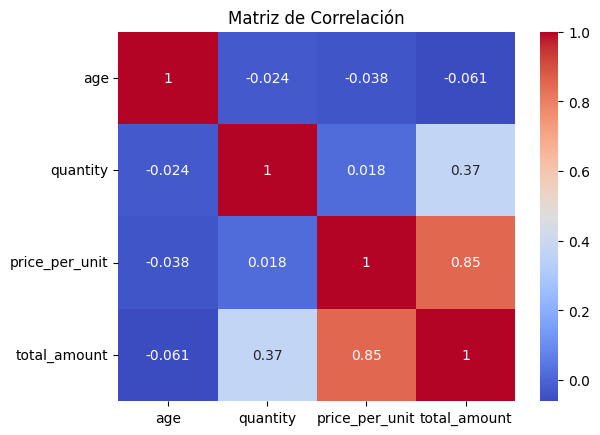

In [69]:
# Mapa de calor
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

###1.3 Visualización de Datos:
* Crear subplots para comparar diferentes variables clave.
* Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información.

<ipython-input-70-d442b611b260>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='product_category', y='total_amount', data=df, palette='coolwarm', ax=axs[0, 0])
<ipython-input-70-d442b611b260>:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_quantity = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)
<ipython-input-70-d442b611b260>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_quantity.index, y=category_quantity.values, palette='magma', ax=axs[1

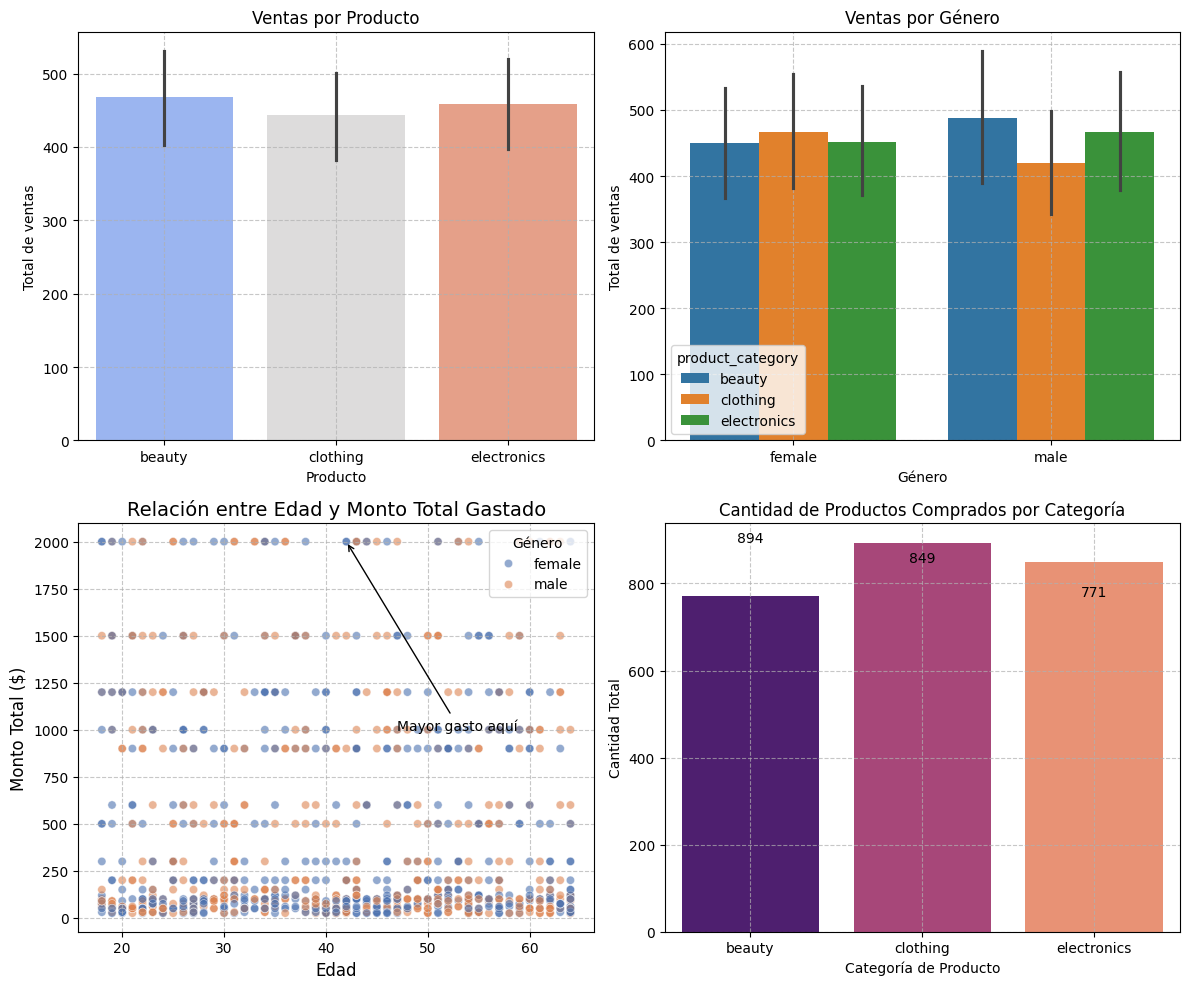

In [70]:
# Subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1. Ventas de producto por total
sns.barplot(x='product_category', y='total_amount', data=df, palette='coolwarm', ax=axs[0, 0])
axs[0, 0].set_title('Ventas por Producto')
axs[0, 0].set_xlabel('Producto')
axs[0, 0].set_ylabel('Total de ventas')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2. Venta de género por total filtrado por producto
sns.barplot(x='gender', y='total_amount', data=df, hue='product_category', ax=axs[0, 1])
axs[0, 1].set_title('Ventas por Género')
axs[0, 1].set_xlabel('Género')
axs[0, 1].set_ylabel('Total de ventas')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Gráfico 3. Relación entre Edad y Monto Total Gastado
sns.scatterplot(x='age', y='total_amount', hue='gender', data=df, palette='deep', alpha=0.6, ax=axs[1, 0])
axs[1, 0].set_title('Relación entre Edad y Monto Total Gastado', fontsize=14)
axs[1, 0].set_xlabel('Edad', fontsize=12)
axs[1, 0].set_ylabel('Monto Total ($)', fontsize=12)
axs[1, 0].legend(title='Género')
axs[1, 0].grid(axis='both', linestyle='--', alpha=0.7)
# Añadir anotación
top_age = df.loc[df['total_amount'].idxmax(), 'age']
top_amount = df['total_amount'].max()
axs[1, 0].annotate('Mayor gasto aquí',
                   xy=(top_age, top_amount),
                   xytext=(top_age + 5, top_amount - 1000),
                   arrowprops=dict(facecolor='green', arrowstyle='->'), fontsize=10)

# Gráfico 4. Cantidad de Productos Comprados por Categoría
category_quantity = df.groupby('product_category')['quantity'].sum().sort_values(ascending=False)
sns.barplot(x=category_quantity.index, y=category_quantity.values, palette='magma', ax=axs[1, 1])
axs[1, 1].set_title('Cantidad de Productos Comprados por Categoría')
axs[1, 1].set_xlabel('Categoría de Producto')
axs[1, 1].set_ylabel('Cantidad Total')
axs[1, 1].grid(axis='both', linestyle='--', alpha=0.7)
# Añadir valores en las barras
for i, value in enumerate(category_quantity.values):
    axs[1, 1].text(i, value + 1, str(value), ha='center', fontsize=10)


plt.tight_layout()
plt.show()

# Parte 2: Preprocesamiento de Datos

###2.1. Transformación de Columnas:
* Utilizar ColumnTransformer para aplicar transformaciones específicas a diferentes columnas.
* Realizar codificación de variables categóricas y escalado de variables numéricas.

In [112]:
# Primeramente clasificamos total_amount en categorías para poder aplicar las futuras métricas destinadas para category
bins = [0, df['total_amount'].quantile(0.33), df['total_amount'].quantile(0.66), df['total_amount'].max()]
labels = ['Bajo', 'Medio', 'Alto']
df['total_amount_class'] = pd.cut(df['total_amount'], bins=bins, labels=labels, include_lowest=True)

# Verificar la distribución de las clases
print(df['total_amount_class'].value_counts())

total_amount_class
Medio    352
Bajo     349
Alto     299
Name: count, dtype: int64


In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 1. Separamos X e y
X = df.drop(['total_amount', 'total_amount_class'], axis=1)  # Excluimos ambas columnas
y = df['total_amount_class']  # Variable objetivo categórica

# 2. Clasificamos 'total_amount' y codificar 'total_amount_class' con LabelEncoder
label_encoder = LabelEncoder()
df['total_amount_class_encoded'] = label_encoder.fit_transform(df['total_amount_class'])
y_encoded = label_encoder.fit_transform(y)  # Codificar 'Alto', 'Bajo', 'Medio'

# 3. Identificar columnas categóricas y numéricas
numerical_columns = df.select_dtypes(include=[np.number]).drop('total_amount', axis=1).columns
categorical_columns = df.select_dtypes(include=['category']).drop('total_amount_class', axis=1).columns

# Definimos las transformaciones
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),  # Escalado de variables numéricas
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns)  # Codificación de variables categóricas
    ]
)

###2.2 Pipelines:
* Crear pipelines para automatizar el preprocesamiento de datos y asegurar la reproducibilidad.

In [114]:
# 4. Creo el pipeline de preprocesamiento
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))  # Modelo inicial
])

# 5. Validación cruzada
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1_macro': make_scorer(f1_score, average='macro')  # Para multiclase
}

###Parte 3: Benchmarking de Técnicas de Machine Learning

1. Selección de Modelos:
* Entrenar y evaluar múltiples modelos de machine learning (por ejemplo, Regresión Lineal, KNN, Árbol de Decisión, Random Forest, XGBoost y LGBM).

* Utilizar validación cruzada para evaluar el rendimiento de los modelos.

In [115]:
# Probar con varios modelos usando validación cruzada
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

results = []

for name, model in models.items():
    # Crear pipeline con el modelo actual
    pipeline.set_params(classifier=model)

    # Realizar validación cruzada
    cv_scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='accuracy')
    results.append({
        "Model": name,
        "Mean Accuracy": cv_scores.mean(),
        "Std Dev": cv_scores.std()
    })

# Convertir resultados en un DataFrame para visualización
results_df = pd.DataFrame(results)

# Mostrar resultados
print("\nResultados de Validación Cruzada:")
print(results_df)


Resultados de Validación Cruzada:
                 Model  Mean Accuracy  Std Dev
0  Logistic Regression            1.0      0.0
1        Decision Tree            1.0      0.0
2        Random Forest            1.0      0.0
3              XGBoost            1.0      0.0


2. Comparación de Modelos:
* Comparar los modelos utilizando métricas de rendimiento como exactitud, precisión, recall, F1-Score y ROC-AUC.
* Seleccionar el mejor modelo basado en las métricas obtenidas.

In [116]:
# Comparar modelos con métricas detalladas
metrics_results = []

for name, model in models.items():
    # Crear pipeline con el modelo actual
    pipeline.set_params(classifier=model)

    # Validación cruzada con métricas
    accuracy_scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='accuracy')
    f1_scores = cross_val_score(pipeline, X, y_encoded, cv=5, scoring='f1_macro')  # Macro para multiclase

    # Ajustar el modelo completo para calcular probabilidades
    pipeline.fit(X, y_encoded)
    y_pred = pipeline.predict(X)
    y_pred_proba = (
        pipeline.predict_proba(X) if hasattr(pipeline.named_steps['classifier'], "predict_proba") else None
    )

    # Calcular métricas adicionales
    precision = precision_score(y_encoded, y_pred, average='macro')
    recall = recall_score(y_encoded, y_pred, average='macro')
    roc_auc = roc_auc_score(y_encoded, y_pred_proba, multi_class='ovr') if y_pred_proba is not None else None

    # Guardar resultados
    metrics_results.append({
        "Model": name,
        "Mean Accuracy (CV)": accuracy_scores.mean(),
        "Std Accuracy (CV)": accuracy_scores.std(),
        "Mean F1-Score (CV)": f1_scores.mean(),
        "Precision": precision,
        "Recall": recall,
        "ROC-AUC": roc_auc
    })

# Crear un DataFrame con los resultados
metrics_df = pd.DataFrame(metrics_results)

# Ordenar por F1-Score (CV)
metrics_df = metrics_df.sort_values(by="Mean F1-Score (CV)", ascending=False)

print("\nComparación de Métricas de Modelos:")
print(metrics_df)



Comparación de Métricas de Modelos:
                 Model  Mean Accuracy (CV)  Std Accuracy (CV)  \
0  Logistic Regression                 1.0                0.0   
1        Decision Tree                 1.0                0.0   
2        Random Forest                 1.0                0.0   
3              XGBoost                 1.0                0.0   

   Mean F1-Score (CV)  Precision  Recall  ROC-AUC  
0                 1.0        1.0     1.0      1.0  
1                 1.0        1.0     1.0      1.0  
2                 1.0        1.0     1.0      1.0  
3                 1.0        1.0     1.0      1.0  


# Parte 4: Análisis de Métricas

### 4.1 Informe de Clasificación:
* Generar un informe de clasificación para los modelos evaluados.
* Incluir la matriz de confusión para una comprensión detallada de los errores de clasificación.

In [117]:
from sklearn.metrics import classification_report, confusion_matrix

# Análisis de métricas detallado para cada modelo
for name, model in models.items():
    print(f"\nModelo: {name}")

    # Actualizar el pipeline con el modelo actual
    pipeline.set_params(classifier=model)

    # Entrenar el pipeline completo con X y y_encoded
    pipeline.fit(X, y_encoded)

    # Predicciones en X
    y_pred = pipeline.predict(X)

    # Generar informe de clasificación
    print("\nInforme de Clasificación:")
    print(classification_report(y_encoded, y_pred, target_names=label_encoder.classes_))


Modelo: Logistic Regression

Informe de Clasificación:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       299
        Bajo       1.00      1.00      1.00       349
       Medio       1.00      1.00      1.00       352

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Modelo: Decision Tree

Informe de Clasificación:
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       299
        Bajo       1.00      1.00      1.00       349
       Medio       1.00      1.00      1.00       352

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Modelo: Random Forest

Informe de Clasificación:
              precision    recall  f1-score   support

        Alto       1.00    

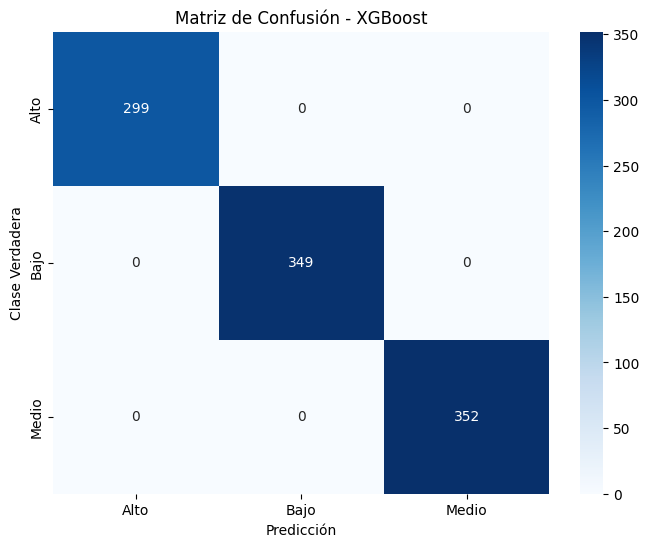

In [118]:
    # Generar matriz de confusión
    cm = confusion_matrix(y_encoded, y_pred)

    # Visualizar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Clase Verdadera")
    plt.show()

###4.2 Curva ROC y AUC:
* Crear y visualizar la curva ROC para los modelos de clasificación binaria.
* Calcular el AUC para evaluar la capacidad del modelo para distinguir entre clases.


Modelo: Logistic Regression


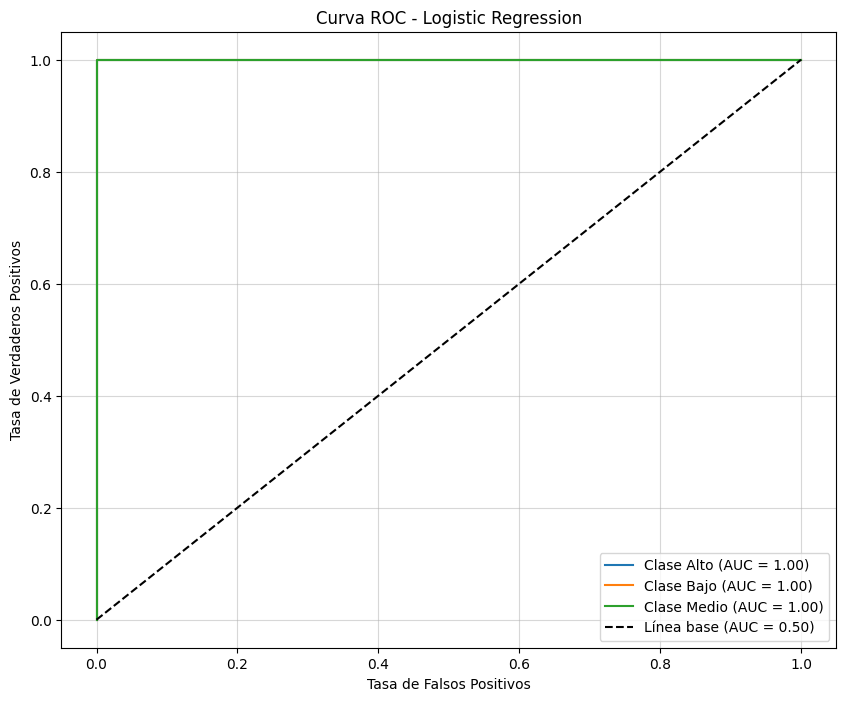

AUC Promedio (Macro): 1.00

Modelo: Decision Tree


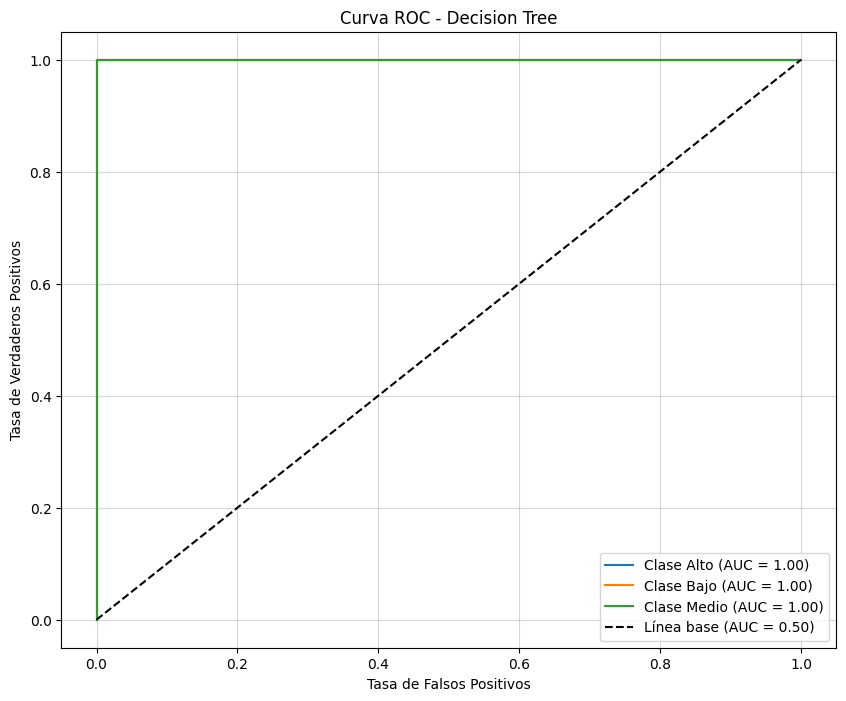

AUC Promedio (Macro): 1.00

Modelo: Random Forest


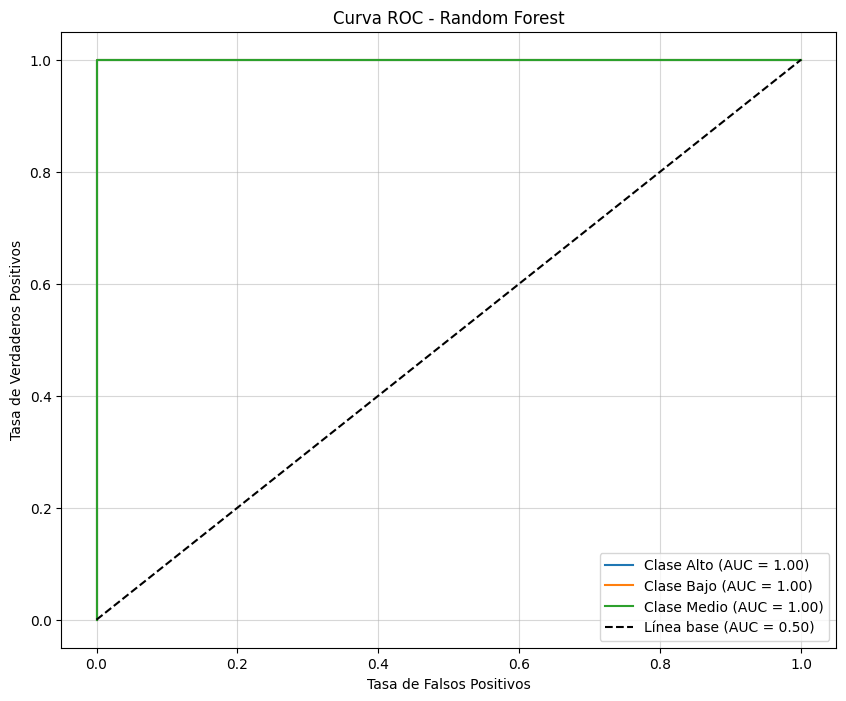

AUC Promedio (Macro): 1.00

Modelo: XGBoost


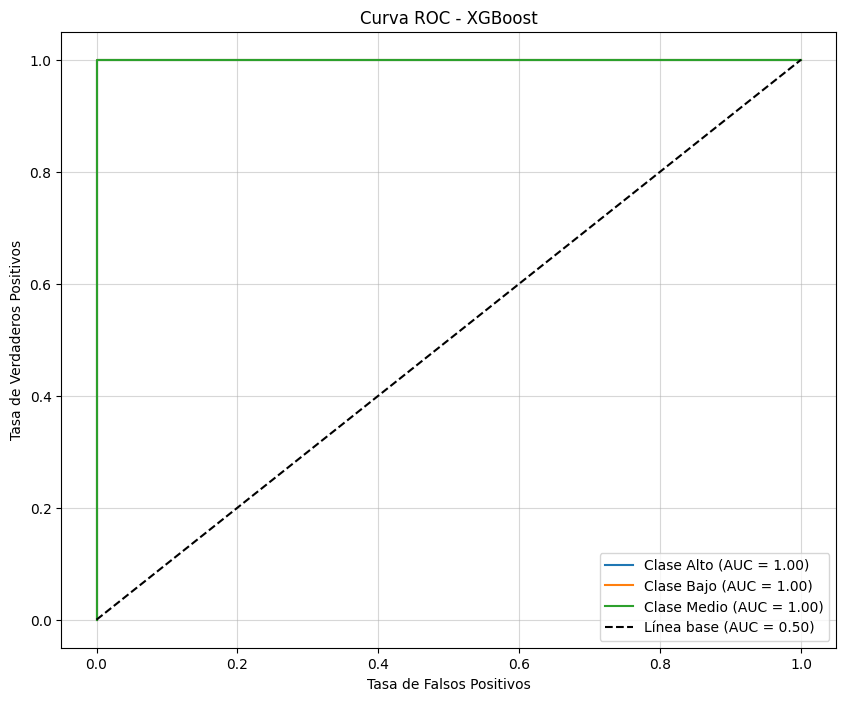

AUC Promedio (Macro): 1.00


In [119]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Curva ROC y AUC para cada modelo
for name, model in models.items():
    print(f"\nModelo: {name}")

    # Actualizar el pipeline con el modelo actual
    pipeline.set_params(classifier=model)
    pipeline.fit(X, y_encoded)

    # Predicciones de probabilidad
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_proba = pipeline.predict_proba(X)

        # Crear curvas ROC para cada clase (OvR)
        fpr = {}  # Falsos Positivos por clase
        tpr = {}  # Verdaderos Positivos por clase
        roc_auc = {}  # AUC por clase

        for i, class_name in enumerate(label_encoder.classes_):
            fpr[class_name], tpr[class_name], _ = roc_curve(y_encoded == i, y_proba[:, i])
            roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

        # Promedio macro
        all_fpr = np.unique(np.concatenate([fpr[c] for c in label_encoder.classes_]))
        mean_tpr = np.zeros_like(all_fpr)
        for c in label_encoder.classes_:
            mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
        mean_tpr /= len(label_encoder.classes_)
        macro_auc = auc(all_fpr, mean_tpr)

        # Graficar curvas ROC por clase
        plt.figure(figsize=(10, 8))
        for class_name in label_encoder.classes_:
            plt.plot(fpr[class_name], tpr[class_name], label=f"Clase {class_name} (AUC = {roc_auc[class_name]:.2f})")
        plt.plot([0, 1], [0, 1], "k--", label="Línea base (AUC = 0.50)")
        plt.title(f"Curva ROC - {name}")
        plt.xlabel("Tasa de Falsos Positivos")
        plt.ylabel("Tasa de Verdaderos Positivos")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.5)
        plt.show()

        print(f"AUC Promedio (Macro): {macro_auc:.2f}")
    else:
        print("Este modelo no soporta predict_proba y no puede generar una curva ROC.")